In [2]:

pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:

pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("https://raw.githubusercontent.com/raveendran2862/dataset/refs/heads/main/diabetes_dataset.csv")
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [9]:
df.shape

(100000, 16)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  diabetes    

In [11]:
obj =df.select_dtypes(include=['object'])
obj

,gender,location,smoking_history
0,Female,Alabama,never
1,Female,Alabama,never
2,Male,Alabama,never
3,Male,Alabama,never
4,Female,Alabama,never
...,...,...,...
99995,Female,Wyoming,never
99996,Female,Wyoming,No Info
99997,Male,Wyoming,ever
99998,Female,Wyoming,not current


In [12]:
obj['gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [13]:
obj['location'].nunique()

55

In [14]:
df.duplicated().sum()

np.int64(14)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


In [17]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 99986, dtype: bool

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['location']=le.fit_transform(df['location']) 
df['smoking_history']=le.fit_transform(df['smoking_history'])

In [19]:
df.corr()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
year,1.000000,0.001083,-0.003303,-0.062230,-0.004282,-0.007287,0.010585,0.004175,-0.003139,-0.003787,0.001834,-0.006483,-0.001861,-0.000460,0.002985,-0.003444
gender,0.001083,1.000000,-0.030636,-0.001549,0.001697,0.000017,-0.004072,0.002190,0.000156,0.014217,0.077711,-0.077895,-0.022996,0.019963,0.017198,0.037428
age,-0.003303,-0.030636,1.000000,0.005382,-0.002249,0.003934,0.003746,0.001929,-0.007338,0.251194,0.233375,0.228677,0.337426,0.101398,0.110690,0.258032
location,-0.062230,-0.001549,0.005382,1.000000,-0.003006,0.000944,-0.001996,0.004943,-0.000867,0.005728,0.004392,0.003602,-0.000210,0.003129,0.002656,-0.000126
race:AfricanAmerican,-0.004282,0.001697,-0.002249,-0.003006,1.000000,-0.251825,-0.250770,-0.250880,-0.251754,-0.001207,-0.000668,0.006198,-0.001249,0.001339,0.002268,0.004372
race:Asian,-0.007287,0.000017,0.003934,0.000944,-0.251825,1.000000,-0.249105,-0.249215,-0.250083,0.004015,0.006194,-0.002291,0.005240,-0.000463,0.000222,0.003780
race:Caucasian,0.010585,-0.004072,0.003746,-0.001996,-0.250770,-0.249105,1.000000,-0.248171,-0.249035,0.000505,-0.001224,0.003554,-0.002114,-0.004086,0.004140,-0.001747
race:Hispanic,0.004175,0.002190,0.001929,0.004943,-0.250880,-0.249215,-0.248171,1.000000,-0.249145,0.001357,-0.000780,-0.005564,0.002363,0.000465,-0.002712,-0.001314
race:Other,-0.003139,0.000156,-0.007338,-0.000867,-0.251754,-0.250083,-0.249035,-0.249145,1.000000,-0.004661,-0.003524,-0.001926,-0.004236,0.002730,-0.003924,-0.005116
hypertension,-0.003787,0.014217,0.251194,0.005728,-0.001207,0.004015,0.000505,0.001357,-0.004661,1.000000,0.121255,0.093164,0.147667,0.080942,0.084424,0.197814


In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 99986 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  99986 non-null  int64  
 1   gender                99986 non-null  int64  
 2   age                   99986 non-null  float64
 3   location              99986 non-null  int64  
 4   race:AfricanAmerican  99986 non-null  int64  
 5   race:Asian            99986 non-null  int64  
 6   race:Caucasian        99986 non-null  int64  
 7   race:Hispanic         99986 non-null  int64  
 8   race:Other            99986 non-null  int64  
 9   hypertension          99986 non-null  int64  
 10  heart_disease         99986 non-null  int64  
 11  smoking_history       99986 non-null  int64  
 12  bmi                   99986 non-null  float64
 13  hbA1c_level           99986 non-null  float64
 14  blood_glucose_level   99986 non-null  int64  
 15  diabetes              99986 non-nul

<Axes: >

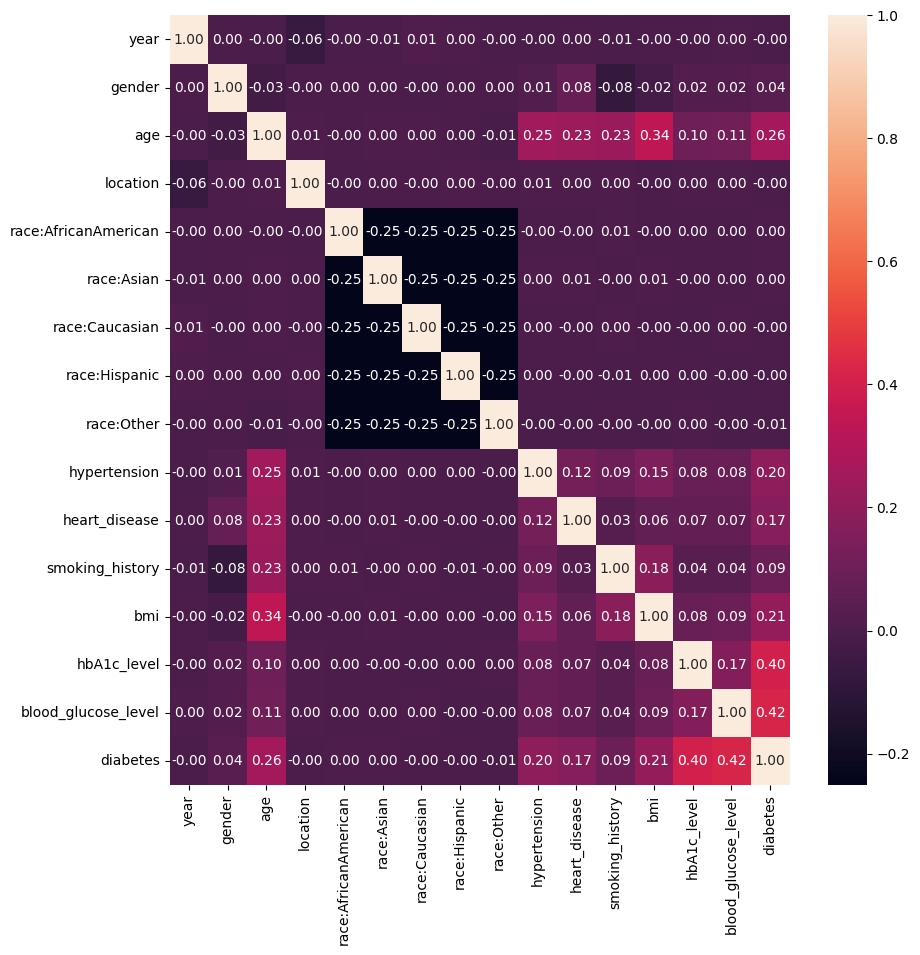

In [21]:
#for example in a  heat map
plt.figure(figsize=(10,10))
#to increase the size of the figure
sns.heatmap(df.corr(),fmt = '.2f',annot=True)

In [22]:
x =df.drop('diabetes',axis=1)
y = df['diabetes']
x

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level
0,2020,0,32.0,0,0,0,0,0,1,0,0,4,27.32,5.0,100
1,2015,0,29.0,0,0,1,0,0,0,0,0,4,19.95,5.0,90
2,2015,1,18.0,0,0,0,0,0,1,0,0,4,23.76,4.8,160
3,2015,1,41.0,0,0,0,1,0,0,0,0,4,27.32,4.0,159
4,2016,0,52.0,0,1,0,0,0,0,0,0,4,23.75,6.5,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,0,33.0,54,0,0,0,0,1,0,0,4,21.21,6.5,90
99996,2016,0,80.0,54,0,1,0,0,0,0,0,0,36.66,5.7,100
99997,2018,1,46.0,54,0,1,0,0,0,0,0,2,36.12,6.2,158
99998,2018,0,51.0,54,1,0,0,0,0,0,0,5,29.29,6.0,155


In [31]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 99986, dtype: int64

In [32]:
y.value_counts()

diabetes
0    91486
1     8500
Name: count, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=9)
x_train.shape

(89987, 15)

In [42]:
x_test.shape


(9999, 15)

In [43]:
y_train.shape

(89987,)

In [44]:
x_train

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level
55632,2019,0,47.0,27,0,1,0,0,0,0,0,4,27.32,6.6,145
12415,2016,0,64.0,6,0,0,1,0,0,0,0,3,22.31,3.5,155
65881,2019,0,46.0,32,1,0,0,0,0,0,0,0,52.67,5.0,160
15103,2019,0,41.0,7,0,1,0,0,0,0,0,5,36.58,6.0,145
62580,2019,1,51.0,31,1,0,0,0,0,0,0,4,31.28,6.6,126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22586,2019,1,58.0,11,0,0,0,0,1,0,0,4,41.14,6.5,155
65471,2019,1,80.0,32,0,0,1,0,0,1,0,0,27.32,5.7,85
66046,2019,1,45.0,32,0,0,0,1,0,0,0,1,22.52,3.5,140
55939,2019,1,13.0,27,0,0,1,0,0,0,0,0,18.65,5.0,155


In [45]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
y_train_predict =  lr.predict(x_test)
y_train_predict


array([0, 0, 1, ..., 0, 0, 0], shape=(9999,))

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_train_predict,y_test)

0.9547954795479549

In [28]:
lr.fit(x_test,y_test)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [72]:
y_test_predict =  lr.predict(x_train)
y_test_predict

array([0, 0, 0, ..., 0, 0, 0], shape=(89987,))

In [73]:
accuracy_score(y_test_predict,y_train)

0.9587384844477536

In [29]:
x_predict = lr.predict(x_train)
x_predict

array([0, 0, 0, ..., 0, 0, 0], shape=(79988,))

In [30]:
accuracy_score(x_predict,y_train)


0.958581287193079

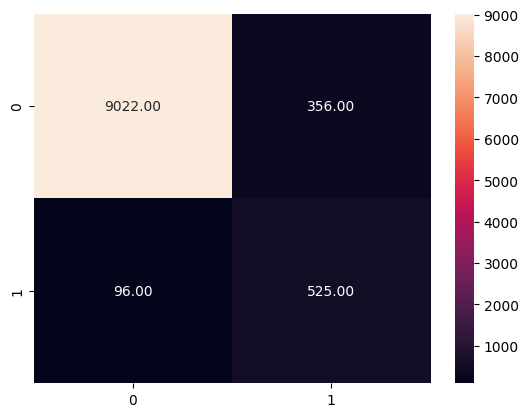

In [60]:
#train --> 95
#test --> 45
sns.heatmap(confusion_matrix(y_train_predict,y_test),annot = True,fmt = '.2f');

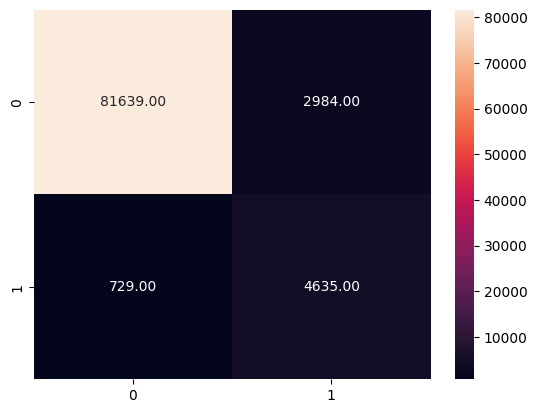

In [74]:
sns.heatmap(confusion_matrix(y_test_predict,y_train),annot = True,fmt = '.2f');

In [65]:
print(classification_report(y_train_predict,y_test))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      9378
           1       0.60      0.85      0.70       621

    accuracy                           0.95      9999
   macro avg       0.79      0.90      0.84      9999
weighted avg       0.97      0.95      0.96      9999



In [75]:
print(classification_report(y_test_predict,y_train))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     84623
           1       0.61      0.86      0.71      5364

    accuracy                           0.96     89987
   macro avg       0.80      0.91      0.85     89987
weighted avg       0.97      0.96      0.96     89987

